In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
import shutil
import random

random.seed(42)

PROJECT_ROOT = Path("../")

BATTEN_SOURCE = PROJECT_ROOT / "data" / "mri_dataset" / "batten"
NORMAL_SOURCE = PROJECT_ROOT / "data" / "mri_dataset" / "non_batten"

MRI_WORKING_DIR = PROJECT_ROOT / "data" / "mri_training"

BATTEN_TRAIN_DIR = MRI_WORKING_DIR / "batten"
NORMAL_TRAIN_DIR = MRI_WORKING_DIR / "non_batten"

# Start fresh
if MRI_WORKING_DIR.exists():
    shutil.rmtree(MRI_WORKING_DIR)

BATTEN_TRAIN_DIR.mkdir(parents=True)
NORMAL_TRAIN_DIR.mkdir(parents=True)

# Collect images
batten_images = [
    p for p in BATTEN_SOURCE.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
]

normal_images = [
    p for p in NORMAL_SOURCE.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
]

# Use 2x normal images
normal_count = min(len(normal_images), len(batten_images) * 2)

selected_normal = random.sample(normal_images, normal_count)

# Copy Batten images
for i, image in enumerate(batten_images):
    shutil.copy2(image, BATTEN_TRAIN_DIR / f"batten_{i:03d}{image.suffix.lower()}")

# Copy selected normal images
for i, image in enumerate(selected_normal):
    shutil.copy2(image, NORMAL_TRAIN_DIR / f"normal_{i:03d}{image.suffix.lower()}")

print("Batten images:", len(batten_images))
print("Normal images:", len(selected_normal))
print("Working dataset:", MRI_WORKING_DIR)

Batten images: 41
Normal images: 82
Working dataset: ..\data\mri_training


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/mri_training",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    color_mode="rgb"
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/mri_training",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    color_mode="rgb"
)

print("Classes:", train_ds.class_names)

Found 123 files belonging to 2 classes.
Using 99 files for training.
Found 123 files belonging to 2 classes.
Using 24 files for validation.
Classes: ['batten', 'non_batten']


In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

In [5]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

mri_model = models.Model(inputs, outputs)

mri_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mri_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
history = mri_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10


c:\Users\Adithya\OneDrive\Desktop\Batten_Disease_Prediction_Using_AI\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 702ms/step - accuracy: 0.5657 - loss: 0.7055 - val_accuracy: 0.6667 - val_loss: 0.6731
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.5758 - loss: 0.7191 - val_accuracy: 0.6667 - val_loss: 0.6614
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 367ms/step - accuracy: 0.6162 - loss: 0.6455 - val_accuracy: 0.6667 - val_loss: 0.6488
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - accuracy: 0.5758 - loss: 0.6779 - val_accuracy: 0.6667 - val_loss: 0.6383
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.6364 - loss: 0.6581 - val_accuracy: 0.6667 - val_loss: 0.6287
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.6162 - loss: 0.6456 - val_accuracy: 0.6667 - val_loss: 0.6201
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step - accuracy: 0.6566 - loss: 0.6289 - val_accuracy: 0.6667 - val_loss: 0.6111
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.5960 - loss: 0.6411 - val_accuracy: 0.6667 - val

In [7]:
MODEL_PATH = "../models/batten_mri_efficientnet.keras"

mri_model.save(MODEL_PATH)

print("MRI model saved successfully!")
print(MODEL_PATH)

MRI model saved successfully!
../models/batten_mri_efficientnet.keras


In [8]:
import tensorflow as tf
from pathlib import Path

MODEL_PATH = "../models/batten_mri_efficientnet.keras"

mri_model = tf.keras.models.load_model(MODEL_PATH)

print("MRI model loaded successfully.")
print("Input shape:", mri_model.input_shape)
print("Output shape:", mri_model.output_shape)

MRI model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


In [9]:
for layer in mri_model.layers:
    print(layer.name, layer.output_shape if hasattr(layer, "output_shape") else "")

input_layer_1 
sequential (None, 224, 224, 3)
efficientnetb0 (None, 7, 7, 1280)
global_average_pooling2d 
dropout 
dense 


In [10]:
base_model = None

for layer in mri_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

for layer in base_model.layers[-20:]:
    print(layer.name, layer.__class__.__name__)

Base model: sequential
random_rotation RandomRotation
random_zoom RandomZoom
random_contrast RandomContrast


In [11]:
from PIL import Image
import numpy as np

batten_dir = Path("../data/mri_dataset/batten")

batten_files = [
    p for p in batten_dir.iterdir()
    if p.suffix.lower() in {
        ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"
    }
]

test_image_path = batten_files[0]

print("Testing image:", test_image_path.name)

image = Image.open(test_image_path).convert("RGB")
image = image.resize((224, 224))

img_array = np.array(image, dtype=np.float32)
img_array = np.expand_dims(img_array, axis=0)

print("Image shape:", img_array.shape)

Testing image: batten_01.png
Image shape: (1, 224, 224, 3)


In [12]:
raw_probability = float(
    mri_model.predict(img_array, verbose=0)[0][0]
)

non_batten_probability = raw_probability
batten_probability = 1.0 - raw_probability

print(f"Batten probability:     {batten_probability:.4f}")
print(f"Non-Batten probability: {non_batten_probability:.4f}")

Batten probability:     0.4701
Non-Batten probability: 0.5299


In [13]:
# Step 68A — Find the last 4D feature layer

base_model = None

for layer in mri_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)

for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            print("Grad-CAM layer:", layer.name)
            break
    except:
        continue

Base model: sequential
Grad-CAM layer: random_contrast


In [15]:
import tensorflow as tf
import numpy as np


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Generate a Grad-CAM heatmap for the MRI model.
    """

    # Find the EfficientNet base model
    base_model = None

    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            break

    if base_model is None:
        raise ValueError("EfficientNet base model not found.")

    # Model that returns the selected convolutional layer
    # and the final model prediction
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            base_model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        # Binary classifier output
        class_channel = predictions[:, 0]

    # Gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients across spatial dimensions
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Weight feature maps by gradients
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [16]:
# Find suitable 4D layers inside EfficientNet

base_model = None

for layer in mri_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print("Base model:", base_model.name)
print()

for layer in reversed(base_model.layers):

    try:
        output_shape = layer.output.shape

        if len(output_shape) == 4:
            print(
                "Candidate Grad-CAM layer:",
                layer.name,
                "| Output:",
                output_shape
            )
            break

    except Exception:
        continue

Base model: sequential

Candidate Grad-CAM layer: random_contrast | Output: (None, 224, 224, 3)


In [18]:
# Step 69A — Identify the EfficientNet base model

print("Model layers:")

for i, layer in enumerate(mri_model.layers):
    print(i, layer.name, type(layer).__name__)

Model layers:
0 input_layer_1 InputLayer
1 sequential Sequential
2 efficientnetb0 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dropout Dropout
5 dense Dense


In [19]:
# Step 69B — Find a suitable convolutional layer

base_model = None

for layer in mri_model.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("EfficientNet base model was not found.")

print("EfficientNet base model:", base_model.name)

print("\nSearching for 4D feature layers...")

candidate_layers = []

for layer in base_model.layers:
    try:
        if len(layer.output.shape) == 4:
            candidate_layers.append(
                (layer.name, tuple(layer.output.shape))
            )
    except:
        pass

print("\nLast 10 candidate layers:")

for name, shape in candidate_layers[-10:]:
    print(name, shape)

last_conv_layer_name = candidate_layers[-1][0]

print("\nSelected Grad-CAM layer:")
print(last_conv_layer_name)

EfficientNet base model: efficientnetb0

Searching for 4D feature layers...

Last 10 candidate layers:
block7a_activation (None, 7, 7, 1152)
block7a_se_reshape (None, 1, 1, 1152)
block7a_se_reduce (None, 1, 1, 48)
block7a_se_expand (None, 1, 1, 1152)
block7a_se_excite (None, 7, 7, 1152)
block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)

Selected Grad-CAM layer:
top_activation


In [20]:
# Step 69C — Correct Grad-CAM function

def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name):

    # Create a model that gives us:
    # 1. convolutional feature maps
    # 2. final prediction

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array,
            training=False
        )

        class_channel = predictions[:, 0]

    # Calculate gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy()

In [22]:
# Step 69A — Inspect the actual model structure

print("Outer model:")
for i, layer in enumerate(mri_model.layers):
    print(i, layer.name, type(layer).__name__)

print("\nEfficientNet layers:")
base_model = None

for layer in mri_model.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    raise ValueError("EfficientNet base model not found.")

print("Base model:", base_model.name)

for i, layer in enumerate(base_model.layers[-15:]):
    print(i - 15, layer.name, type(layer).__name__)

Outer model:
0 input_layer_1 InputLayer
1 sequential Sequential
2 efficientnetb0 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 dropout Dropout
5 dense Dense

EfficientNet layers:
Base model: efficientnetb0
-15 block7a_expand_bn BatchNormalization
-14 block7a_expand_activation Activation
-13 block7a_dwconv DepthwiseConv2D
-12 block7a_bn BatchNormalization
-11 block7a_activation Activation
-10 block7a_se_squeeze GlobalAveragePooling2D
-9 block7a_se_reshape Reshape
-8 block7a_se_reduce Conv2D
-7 block7a_se_expand Conv2D
-6 block7a_se_excite Multiply
-5 block7a_project_conv Conv2D
-4 block7a_project_bn BatchNormalization
-3 top_conv Conv2D
-2 top_bn BatchNormalization
-1 top_activation Activation


In [23]:
# Step 69B — Robust Grad-CAM function

def make_gradcam_heatmap(img_array, model, base_model, layer_name):

    # Get the requested feature layer
    target_layer = base_model.get_layer(layer_name)

    # Build a model directly from EfficientNet input
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=target_layer.output
    )

    # Get EfficientNet features
    with tf.GradientTape() as tape:

        conv_features = feature_model(
            img_array,
            training=False
        )

        tape.watch(conv_features)

        # Continue through the original classification head
        x = base_model.output

        # We need the prediction corresponding to the actual model.
        # Use the complete model for the gradient calculation instead.
        prediction = model(img_array, training=False)

        class_score = prediction[:, 0]

    # Gradient of prediction with respect to feature maps
    gradients = tape.gradient(
        class_score,
        conv_features
    )

    if gradients is None:
        raise ValueError(
            "Gradients could not be calculated for the selected layer."
        )

    # Average gradients spatially
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_features = conv_features[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_features * pooled_gradients,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    maximum = tf.reduce_max(heatmap)

    heatmap = tf.where(
        maximum > 0,
        heatmap / maximum,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [24]:
# Step 69B — Final Grad-CAM implementation

def make_gradcam_heatmap(img_array, base_model, classifier_head, layer_name):

    target_layer = base_model.get_layer(layer_name)

    # Model: image -> target convolutional features
    feature_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=target_layer.output
    )

    with tf.GradientTape() as tape:

        # Extract feature maps
        conv_outputs = feature_model(
            img_array,
            training=False
        )

        # Continue forward from target layer to base-model output
        x = conv_outputs

        target_index = base_model.layers.index(target_layer)

        for layer in base_model.layers[target_index + 1:]:
            x = layer(x, training=False)

        # Classification head
        x = classifier_head(x, training=False)

        class_score = x[:, 0]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    if gradients is None:
        raise ValueError(
            "Could not calculate Grad-CAM gradients."
        )

    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_gradients,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    maximum = tf.reduce_max(heatmap)

    heatmap = tf.where(
        maximum > 0,
        heatmap / maximum,
        tf.zeros_like(heatmap)
    )

    return heatmap.numpy()

In [25]:
for i, layer in enumerate(mri_model.layers):
    print(
        i,
        "|",
        layer.name,
        "|",
        type(layer).__name__
    )

0 | input_layer_1 | InputLayer
1 | sequential | Sequential
2 | efficientnetb0 | Functional
3 | global_average_pooling2d | GlobalAveragePooling2D
4 | dropout | Dropout
5 | dense | Dense


In [26]:
# Step 69A — Find the final convolutional feature layer

base_model = mri_model.get_layer("efficientnetb0")

print("EfficientNet layers with 4D outputs:")

candidate_layers = []

for layer in base_model.layers:
    try:
        if len(layer.output.shape) == 4:
            candidate_layers.append(layer.name)
    except:
        pass

for name in candidate_layers[-10:]:
    print(name)

last_conv_layer_name = candidate_layers[-1]

print("\nSelected Grad-CAM layer:")
print(last_conv_layer_name)

EfficientNet layers with 4D outputs:
block7a_activation
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation

Selected Grad-CAM layer:
top_activation


In [27]:
# Step 69B — Create Grad-CAM model

base_model = mri_model.get_layer("efficientnetb0")
target_layer = base_model.get_layer(last_conv_layer_name)

grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        target_layer.output,
        base_model.output
    ]
)

print("Grad-CAM model created successfully.")

Grad-CAM model created successfully.


In [28]:
# Step 69C — Generate Grad-CAM heatmap

with tf.GradientTape() as tape:

    conv_outputs, efficientnet_output = grad_model(
        img_array,
        training=False
    )

    # The classifier score used by our model
    x = efficientnet_output

    x = mri_model.get_layer("global_average_pooling2d")(x)
    x = mri_model.get_layer("dropout")(x, training=False)
    predictions = mri_model.get_layer("dense")(x)

    class_score = predictions[:, 0]

grads = tape.gradient(
    class_score,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(
    heatmap,
    0
)

max_value = tf.reduce_max(heatmap)

heatmap = tf.where(
    max_value > 0,
    heatmap / max_value,
    tf.zeros_like(heatmap)
)

heatmap = heatmap.numpy()

print("Grad-CAM generated successfully.")
print("Heatmap shape:", heatmap.shape)

Grad-CAM generated successfully.
Heatmap shape: (7, 7)


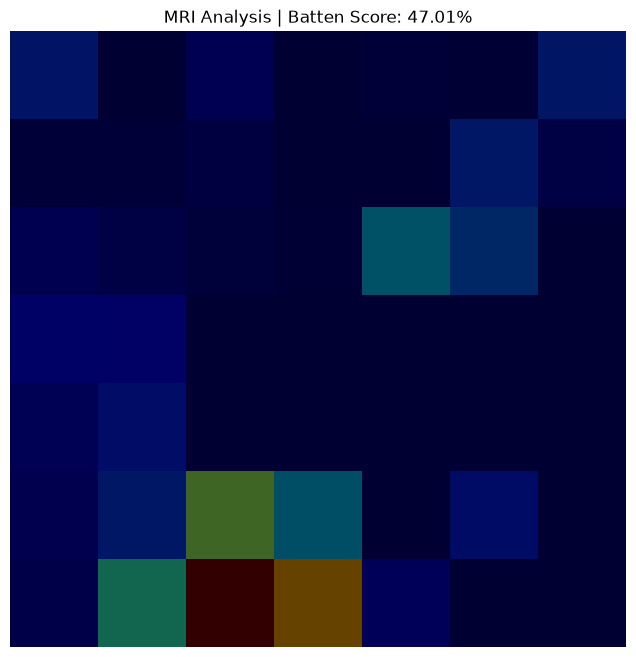

In [29]:
# Step 69D — Display MRI with Grad-CAM

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.4
)

plt.axis("off")

plt.title(
    f"MRI Analysis | Batten Score: {batten_probability:.2%}"
)

plt.show()